# Noodles CSR Survey Analysis
### Problem Statement
Noodles & Company wants to understand which CSR initiatives matter most to customers and how to prioritize them in marketing.

### Objective
• Identify important CSR initiatives

• Understand willingness to pay

• Analyze customer behavior

• Provide marketing recommendations

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import re

In [35]:
noodles_raw = pd.read_excel(r"Noodles Sustainability Survey_Data.xls")
print(noodles_raw.shape)
print(noodles_raw.head(3))


(1038, 47)
  RespondentID  \
0                
1   2872767893   
2   2872750407   

  How likely are you to visit a particular restaurant if they offered the following activities?     \
0          Uses locally-grown produce when in season                                                 
1                                    Somewhat likely                                                 
2                                        Very likely                                                 

                                          Unnamed: 2  \
0  Uses naturally-raised, antibiotic and hormone-...   
1                                                NaN   
2                                        Very likely   

                                    Unnamed: 3           Unnamed: 4  \
0  Serves certified organic meats and proteins  Uses cage-free eggs   
1                                          NaN                  NaN   
2                                  Very likely          Very likely  

In [36]:
print(noodles_raw.iloc[:, 0:10].describe(include='all'))


       RespondentID  \
count          1038   
unique         1038   
top                   
freq              1   

       How likely are you to visit a particular restaurant if they offered the following activities?     \
count                                                 600                                                 
unique                                                  4                                                 
top                                           Very likely                                                 
freq                                                  297                                                 

         Unnamed: 2       Unnamed: 3       Unnamed: 4       Unnamed: 5  \
count           574              580              577              523   
unique            4                4                4                4   
top     Very likely  Somewhat likely  Somewhat likely  Somewhat likely   
freq            274              254              26

### Data Cleaning

In [37]:
noodles = noodles_raw.iloc[1:].copy()
print(noodles.shape)

(1037, 47)


In [38]:
#Clean column names

def clean_names(columns):
    cleaned = []
    for col in columns:
        col = col.strip().lower()
        col = re.sub(r"[^\w]+", "_", col)
        cleaned.append(col)
    return cleaned

noodles.columns = clean_names(noodles.columns)

print(noodles.columns)

Index(['respondentid',
       'how_likely_are_you_to_visit_a_particular_restaurant_if_they_offered_the_following_activities_',
       'unnamed_2', 'unnamed_3', 'unnamed_4', 'unnamed_5', 'unnamed_6',
       'unnamed_7', 'unnamed_8', 'unnamed_9', 'unnamed_10', 'unnamed_11',
       'unnamed_12',
       'oftentimes_serving_and_providing_sustainable_and_organic_ingredients_costs_more_to_produce_which_drives_up_the_costs_of_menu_items_which_of_these_activities_would_you_be_willing_to_pay_more_for_',
       'unnamed_14', 'unnamed_15', 'unnamed_16', 'unnamed_17', 'unnamed_18',
       'unnamed_19', 'how_often_do_you_volunteer_in_your_community_',
       'how_important_is_it_to_you_to_eat_', 'unnamed_22', 'unnamed_23',
       'unnamed_24', 'unnamed_25', 'unnamed_26', 'tell_us_about_yourself_age',
       'gender', 'education_',
       'what_chain_restaurants_do_you_frequent_and_how_often_', 'unnamed_31',
       'unnamed_32', 'unnamed_33', 'unnamed_34', 'unnamed_35', 'unnamed_36',
       'unnamed_

In [39]:
#  Rename visit columns
noodles.columns.values[1:13] = [
    "local_produce_visit", "natural_proteins_visit", "organic_meats_visit",
    "cage_free_eggs_visit", "low_calorie_visit", "gluten_free_visit",
    "real_dishware_visit", "recycled_packaging_visit", "community_fundraisers_visit",
    "natural_ingredients_visit", "composting_visit", "gmo_free_visit"
]

In [40]:
#  Rename pay columns

noodles.columns.values[13:20] = [
    "pay_local_produce", "pay_natural_proteins", "pay_organic_meats",
    "pay_cage_free_eggs", "pay_gluten_free",
    "pay_sustainable_packaging", "pay_gmo_free"
]

In [41]:
# Rename importance columns

noodles.columns.values[21:27] = [
    "importance_all_natural", "importance_local", "importance_organic",
    "importance_antibiotic_free", "importance_humane", "importance_cage_free"
]


In [42]:
# Rename demographic columns
noodles.rename(columns={
    "gender_1": "gender",
    "location_census_region_": "location_census_region",
    "annual_household_income_": "annual_household_income"
}, inplace=True)



In [43]:
#  Drop unnecessary columns
noodles = noodles.drop(columns=[
    "unnamed_39", "unnamed_40"
], errors='ignore')


In [44]:
#  Cell 13: Rename frequency columns

noodles.columns.values[27:38] = [
    "panera_freq", "chipotle_freq", "qdoba_freq", "potbelly_freq",
    "noodles_freq", "subway_freq", "pei_wei_freq", "olive_garden_freq",
    "panda_express_freq", "five_guys_freq", "other_freq"
]


print(noodles.columns)


Index(['respondentid', 'local_produce_visit', 'natural_proteins_visit',
       'organic_meats_visit', 'cage_free_eggs_visit', 'low_calorie_visit',
       'gluten_free_visit', 'real_dishware_visit', 'recycled_packaging_visit',
       'community_fundraisers_visit', 'natural_ingredients_visit',
       'composting_visit', 'gmo_free_visit', 'pay_local_produce',
       'pay_natural_proteins', 'pay_organic_meats', 'pay_cage_free_eggs',
       'pay_gluten_free', 'pay_sustainable_packaging', 'pay_gmo_free',
       'how_often_do_you_volunteer_in_your_community_',
       'importance_all_natural', 'importance_local', 'importance_organic',
       'importance_antibiotic_free', 'importance_humane',
       'importance_cage_free', 'panera_freq', 'chipotle_freq', 'qdoba_freq',
       'potbelly_freq', 'noodles_freq', 'subway_freq', 'pei_wei_freq',
       'olive_garden_freq', 'panda_express_freq', 'five_guys_freq',
       'other_freq', 'unnamed_38', 'annual_household_income', 'gender', 'age',
       'hous

In [45]:
#  Check noodles frequency

print(noodles["noodles_freq"].describe())
print(noodles["noodles_freq"].unique())


count             1026
unique               5
top       Never/Seldom
freq               399
Name: noodles_freq, dtype: object
['A few times a year' 'One time a month' 'Three or more times a month'
 'Two times a month' 'Never/Seldom' nan]


In [46]:
#  Convert frequency variables to numeric
freq_levels = [
    "Never/Seldom", "A few times a year", "One time a month",
    "Two times a month", "Three or more times a month"
]

for col in noodles.loc[:, "panera_freq":"other_freq"].columns:
    noodles[col] = pd.Categorical(noodles[col], categories=freq_levels, ordered=True)
    noodles[col] = noodles[col].cat.codes + 1
print(noodles["noodles_freq"].describe())

count    1037.000000
mean        2.050145
std         1.186878
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: noodles_freq, dtype: float64


In [47]:
# Convert Likert variables

likert_levels = [
    "Not likely at all", "Somewhat likely", "Very likely"
]

for col in noodles.loc[:, "local_produce_visit":"pay_gmo_free"].columns:
    noodles[col] = pd.Categorical(noodles[col], categories=likert_levels, ordered=True)
    noodles[col] = noodles[col].cat.codes + 1

    print(noodles["natural_proteins_visit"].describe())



count             573
unique              3
top       Very likely
freq              274
Name: natural_proteins_visit, dtype: object
count    1037.000000
mean        1.312440
std         1.280523
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max         3.000000
Name: natural_proteins_visit, dtype: float64
count    1037.000000
mean        1.312440
std         1.280523
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max         3.000000
Name: natural_proteins_visit, dtype: float64
count    1037.000000
mean        1.312440
std         1.280523
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max         3.000000
Name: natural_proteins_visit, dtype: float64
count    1037.000000
mean        1.312440
std         1.280523
min         0.000000
25%         0.000000
50%         1.000000
75%         3.000000
max         3.000000
Name: natural_proteins_visit, dtype: float64
count    1037.00

In [48]:
#  Handle importance variables

for col in noodles.loc[:, "importance_all_natural":"importance_cage_free"].columns:
    noodles[col] = noodles[col].replace("Don't know", np.nan)


importance_levels = [
    "Not at all important", "Of little importance", "Somewhat important",
    "Neutral", "Important", "Very Important"
]

for col in noodles.loc[:, "importance_all_natural":"importance_cage_free"].columns:
    noodles[col] = pd.Categorical(noodles[col], categories=importance_levels, ordered=True)
    noodles[col] = noodles[col].cat.codes + 1


In [49]:
#  Income cleaning
noodles["household_income"] = noodles["household_income"].replace(
    "150000", "$150,000 or more"
)

income_levels = [
    "$0 - $24,999", "$25,000 - $49,999",
    "$50,000 - $99,999", "$100,000 - $149,999",
    "$150,000 or more"
]

noodles["household_income"] = pd.Categorical(
    noodles["household_income"],
    categories=income_levels,
    ordered=True
)

noodles["income_numeric"] = noodles["household_income"].cat.codes + 1



In [50]:
# Cell 22: Convert categorical variables 
noodles["gender"] = noodles["gender"].astype("category")
noodles["location_census_region"] = noodles["location_census_region"].astype("category")
noodles["age"] = noodles["age"].astype("category")


In [51]:
# Dataset info

print(noodles.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1037 entries, 1 to 1037
Data columns (total 46 columns):
 #   Column                                         Non-Null Count  Dtype   
---  ------                                         --------------  -----   
 0   respondentid                                   1037 non-null   object  
 1   local_produce_visit                            1037 non-null   int8    
 2   natural_proteins_visit                         1037 non-null   int8    
 3   organic_meats_visit                            1037 non-null   int8    
 4   cage_free_eggs_visit                           1037 non-null   int8    
 5   low_calorie_visit                              1037 non-null   int8    
 6   gluten_free_visit                              1037 non-null   int8    
 7   real_dishware_visit                            1037 non-null   int8    
 8   recycled_packaging_visit                       1037 non-null   int8    
 9   community_fundraisers_visit              

In [52]:
#  Save cleaned dataset

noodles.to_csv("noodles_cleaned.csv", index=False)



### DEFINE COLUMN GROUPS

In [53]:
csr_cols = [col for col in noodles.columns if col.endswith("_visit")]
pay_cols = [col for col in noodles.columns if col.startswith("pay_")]
importance_cols = [col for col in noodles.columns if col.startswith("importance_")]

Grouped columns based on CSR preferences, willingness to pay, and importance factors.


### CSR ANALYSIS


In [54]:
csr = noodles[csr_cols].mean().sort_values(ascending=False)
csr

local_produce_visit            1.408872
natural_ingredients_visit      1.315333
natural_proteins_visit         1.312440
organic_meats_visit            1.287367
cage_free_eggs_visit           1.282546
gmo_free_visit                 1.203472
community_fundraisers_visit    1.188042
low_calorie_visit              1.186114
composting_visit               1.159113
recycled_packaging_visit       1.132112
gluten_free_visit              1.099325
real_dishware_visit            1.071360
dtype: float64

C:\Users\devar\AppData\Local\Temp\ipykernel_29412\1586750107.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


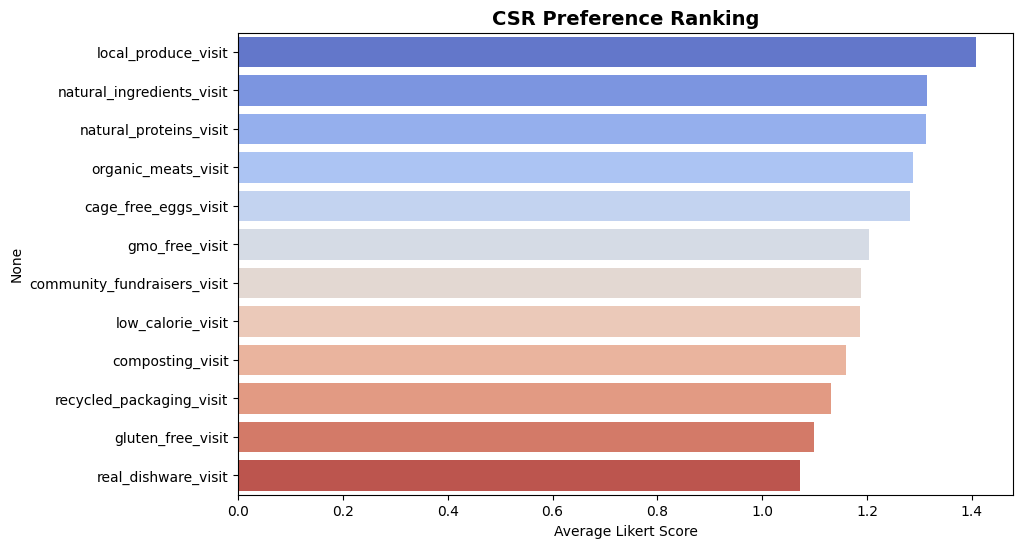

In [55]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=csr.values,
    y=csr.index,
    palette="coolwarm"
)

plt.title("CSR Preference Ranking", fontsize=14, fontweight="bold")
plt.xlabel("Average Likert Score")

plt.show()

This chart shows that customers strongly prefer sustainability initiatives related to food quality, such as local produce and natural ingredients.

In contrast, operational initiatives like recycling and composting have lower influence on customer preference.

This indicates that customers prioritize what they consume over how the business operates.

In [56]:
pay = noodles[pay_cols].mean().sort_values(ascending=False)
pay

pay_local_produce            1.294118
pay_natural_proteins         1.217936
pay_organic_meats            1.162970
pay_cage_free_eggs           1.096432
pay_gmo_free                 1.083896
pay_sustainable_packaging    1.029894
pay_gluten_free              0.949855
dtype: float64

C:\Users\devar\AppData\Local\Temp\ipykernel_29412\288365426.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


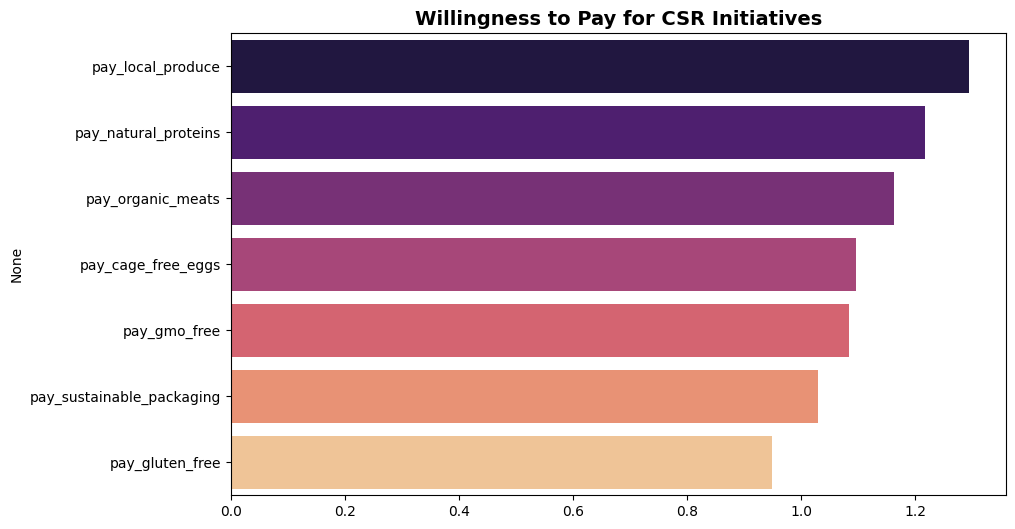

In [57]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=pay.values,
    y=pay.index,
    palette="magma"
)

plt.title("Willingness to Pay for CSR Initiatives", fontsize=14, fontweight="bold")

plt.show()

Customers are more willing to pay for CSR initiatives that directly impact food quality and health, such as organic and natural products.

In contrast, operational or indirect sustainability factors like packaging are less influential when it comes to spending decisions.

In [58]:
importance = noodles[importance_cols].mean().sort_values(ascending=False)
importance

importance_local              4.024108
importance_all_natural        3.985535
importance_humane             3.882353
importance_antibiotic_free    3.759884
importance_cage_free          3.666345
importance_organic            3.601736
dtype: float64

C:\Users\devar\AppData\Local\Temp\ipykernel_29412\567932176.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


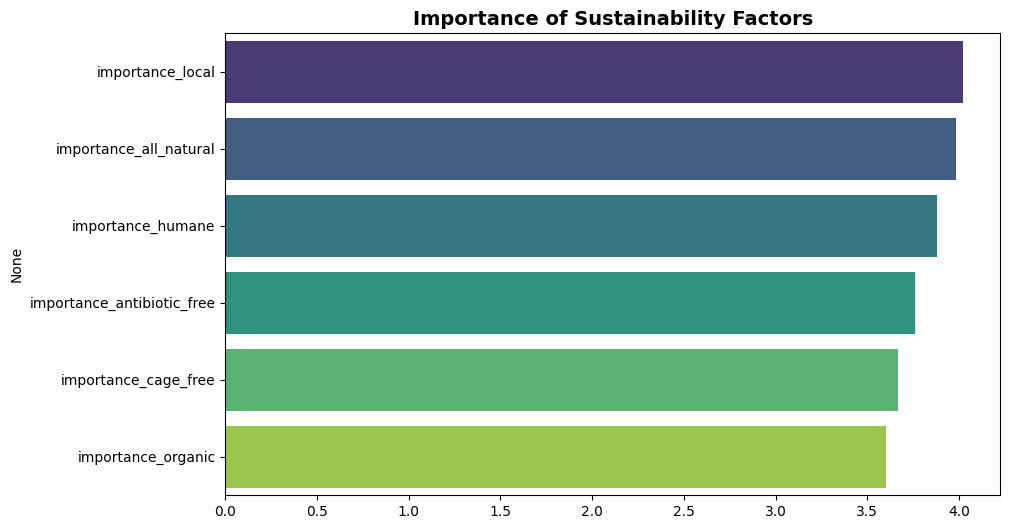

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=importance.values,
    y=importance.index,
    palette="viridis"
)

plt.title("Importance of Sustainability Factors", fontsize=14, fontweight="bold")

plt.show()

Customers place the highest importance on freshness and natural quality of food, followed by ethical and health considerations.

This indicates that customers prioritize what they consume and how it is sourced over labels such as “organic.”

### CUSTOMER BEHAVIOR (VALUE COUNTS)

In [61]:
noodles["how_often_do_you_volunteer_in_your_community_"].value_counts()

how_often_do_you_volunteer_in_your_community_
Multiple times a month           264
Never/Less than once per year    260
1-2 times a year                 260
3-4 times a year                 244
Name: count, dtype: int64

C:\Users\devar\AppData\Local\Temp\ipykernel_29412\487146616.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


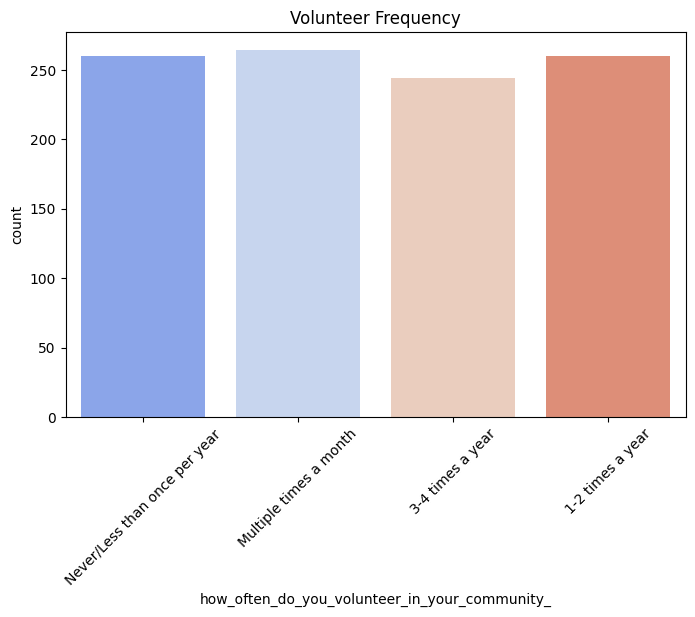

In [62]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="how_often_do_you_volunteer_in_your_community_",
    data=noodles,
    palette="coolwarm"
)

plt.xticks(rotation=45)
plt.title("Volunteer Frequency")

plt.show()

There is no strong dominance of one category, indicating that customer involvement in community activities is diverse.

Some customers are highly engaged in volunteering, while others have limited or no participation.

### DEMOGRAPHIC ANALYSIS

In [64]:
noodles["gender"].value_counts()

gender
Female    535
Male      500
Name: count, dtype: int64

C:\Users\devar\AppData\Local\Temp\ipykernel_29412\1464293542.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="gender", data=noodles, palette="pastel")


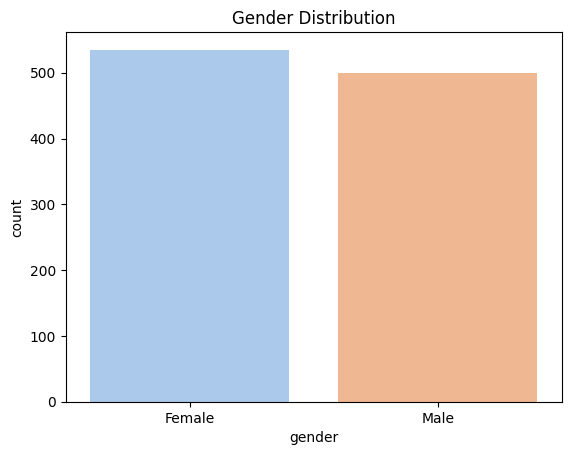

In [65]:
sns.countplot(x="gender", data=noodles, palette="pastel")
plt.title("Gender Distribution")
plt.show()

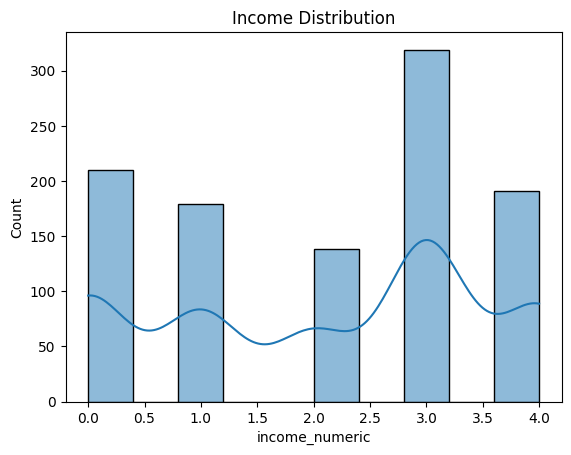

In [66]:
sns.histplot(noodles["income_numeric"], bins=10, kde=True)
plt.title("Income Distribution")
plt.show()

The customer base is slightly skewed toward middle and higher income groups.

This suggests that the majority of customers have moderate to high purchasing power.

C:\Users\devar\AppData\Local\Temp\ipykernel_29412\557882588.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  noodles.groupby("household_income")[csr_cols].mean().T.plot(kind="bar", figsize=(12,6))
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


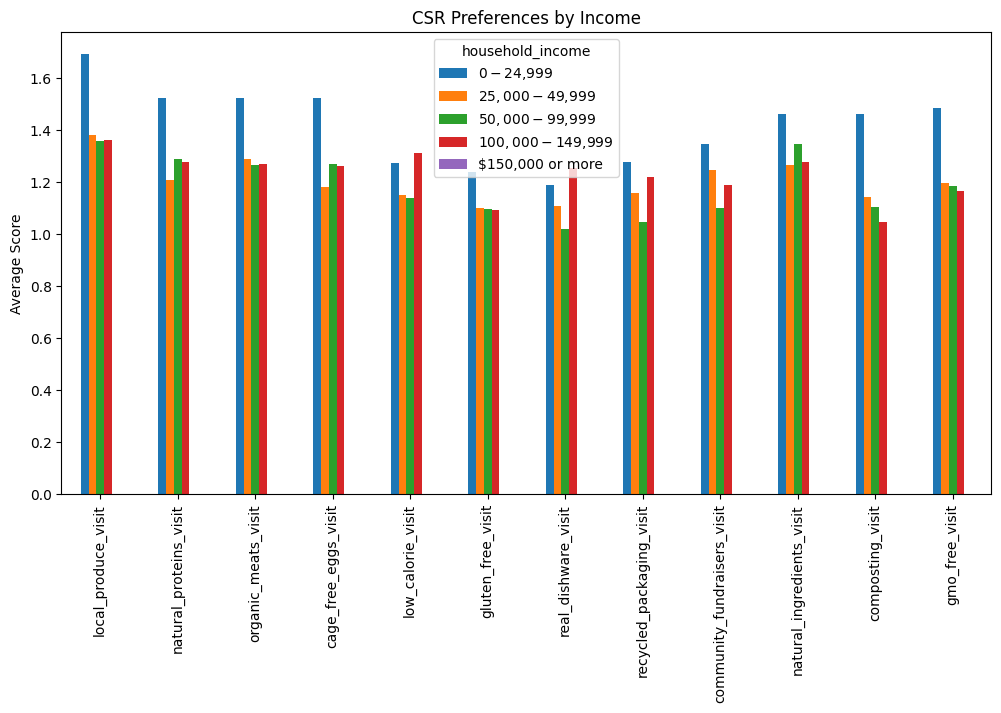

In [67]:
noodles.groupby("household_income")[csr_cols].mean().T.plot(kind="bar", figsize=(12,6))

plt.title("CSR Preferences by Income")
plt.ylabel("Average Score")

plt.show()

Customer preference for sustainability initiatives does not significantly vary across income groups.

This indicates that sustainability is a universal concern, not limited to high-income customers.


## Insights

• Customers show the highest preference for CSR initiatives related to food quality such as local produce, natural ingredients, and organic products.

• Sustainability factors that directly impact health and consumption are more important than operational initiatives like packaging or dishware.

• Customers are willing to pay more for high-quality and sustainable food options, especially for local and natural products.

• Importance analysis shows that customers highly value freshness, natural ingredients, and ethical sourcing such as humane treatment and antibiotic-free products.

• Volunteer behavior indicates mixed levels of social engagement, meaning customers vary in their personal involvement in community activities.

• Income distribution shows a strong presence of mid-to-high income customers, indicating good purchasing power.

• CSR preferences are consistent across all income groups, suggesting sustainability is important to all customers regardless of income level.

## Recommendations

• Focus on promoting high-impact CSR initiatives such as:
  - Local sourcing
  - Natural ingredients
  - Organic products

• Position sustainable products as premium offerings to target mid-to-high income customers.

• Highlight health, quality, and ethical benefits in marketing campaigns.

• Do not rely heavily on low-impact initiatives such as packaging as primary selling points.

• Create awareness campaigns to improve customer understanding of less visible CSR activities like composting and recycling.

• Develop tiered pricing strategies to make sustainable options accessible to different income groups.

• Design inclusive CSR strategies that engage both highly active and less active customers in community initiatives.

## Conclusion

This analysis shows that customers strongly value sustainability, particularly in areas that directly impact food quality, health, and ethical sourcing.

Customers are not only interested in CSR initiatives but are also willing to pay for them, especially when they perceive direct benefits.

The findings also indicate that sustainability preferences are consistent across income groups, making CSR initiatives broadly relevant and scalable.

Overall, businesses can leverage sustainability as a key strategy by focusing on high-impact initiatives, aligning with customer values, and effectively communicating the benefits.